Updated : 2026-06-29

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# UDFs
from src.load_config import load_json_config
from src.display import plot_forecast_comparison # Model output display

# Setup

In [2]:
# Load configuration
schema_config = load_json_config("config/schema.json")
local_config = load_json_config("config/local.json")

In [3]:
print(local_config)

{'combined_data_path': 'data/combined_data.csv', 'output_path': 'outputs'}


In [4]:
# Load data
combined_data = local_config['combined_data_path']
raw_df = pd.read_csv(combined_data)

In [5]:
# Declare variables
kpi = schema_config['kpi']

In [6]:
print(kpi)

sales


In [7]:
raw_df.columns

Index(['month', 'sales', 'dig_aud', 'video_io', 'video_prog', 'display_io',
       'display_prog', 'social_display', 'social_video', 'search_off_weekly',
       ...
       'web_visits_ut', 'cpi', 'petrol_price', 'unemp', 'oao_ut',
       'oao_magnite', 'cftp', 'sales_div_tiv', 'pct_discount', 'fy'],
      dtype='object', length=104)

# Data Cleaning

# Data Processing

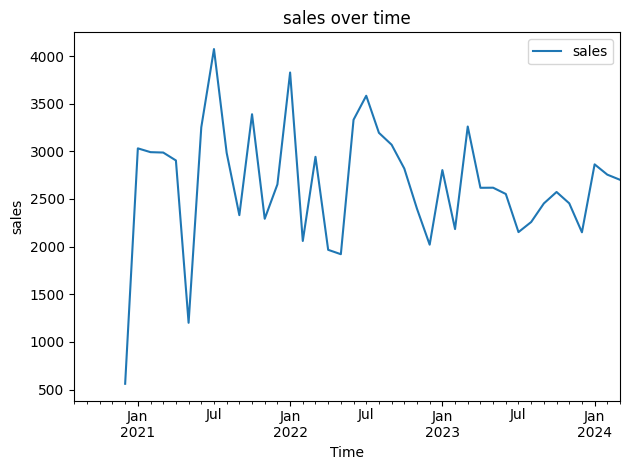

In [8]:
# Plot kpi data in line chart
raw_df["month"] = pd.to_datetime(raw_df["month"], errors="coerce")
ax = raw_df.plot(x="month", y=kpi, kind="line", title=f"{kpi} over time")
ax.set_xlabel("Time")
ax.set_ylabel(kpi)
plt.tight_layout()
plt.show()

In [9]:
# Train Test split
split_ratio = 0.8  # 80% train, 20% test
split_idx = int(len(raw_df) * split_ratio)

train_df = raw_df.iloc[:split_idx].copy()
test_df = raw_df.iloc[split_idx:].copy()

training_period = (train_df["month"].min(), train_df["month"].max())
test_period = (test_df["month"].min(), test_df["month"].max())

# Prophet model using train_df / test_df

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Prepare Prophet input format: ds (date), y (target)
train_prophet = train_df[["month", kpi]].rename(columns={"month": "ds", kpi: "y"}).dropna()
test_prophet = test_df[["month", kpi]].rename(columns={"month": "ds", kpi: "y"}).dropna()


Importing plotly failed. Interactive plots will not work.


In [ ]:
# # Train Test split
# split_ratio = 0.8  # 80% train, 20% test
# split_idx = int(len(raw_df) * split_ratio)

# train_df = raw_df.iloc[:split_idx].copy()
# test_df = raw_df.iloc[split_idx:].copy()

# training_period = (train_df["month"].min(), train_df["month"].max())
# test_period = (test_df["month"].min(), test_df["month"].max())

# from prophet import Prophet
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import numpy as np

# # Candidate independent variables
# candidate_regressors = ["search_off_weekly", "social_display_others"]

# # Keep only regressors present in data
# available_regressors = [c for c in candidate_regressors if c in raw_df.columns]

# # Prepare Prophet input format
# base_cols = ["month", kpi]
# all_cols = base_cols + available_regressors

# train_prophet = train_df[all_cols].rename(columns={"month": "ds", kpi: "y"}).copy()
# test_prophet = test_df[all_cols].rename(columns={"month": "ds", kpi: "y"}).copy()

# # Ensure required fields are valid
# train_prophet = train_prophet.dropna(subset=["ds", "y"])
# test_prophet = test_prophet.dropna(subset=["ds", "y"])

# # Fill missing regressor values (Prophet cannot handle NaN regressors)
# for reg in available_regressors:
#     fill_val = train_prophet[reg].median()
#     if pd.isna(fill_val):
#         fill_val = 0.0
#     train_prophet[reg] = train_prophet[reg].fillna(fill_val)
#     test_prophet[reg] = test_prophet[reg].fillna(fill_val)

# print(f"Using regressors: {available_regressors}" if available_regressors else "No regressors found. Using univariate Prophet.")

# # Fit model
# model = Prophet()
# for reg in available_regressors:
#     model.add_regressor(reg)

# fit_cols = ["ds", "y"] + available_regressors
# model.fit(train_prophet[fit_cols])

# # Predict on test period dates
# future_cols = ["ds"] + available_regressors
# test_future = test_prophet[future_cols].copy()
# forecast_test = model.predict(test_future)

# # Join actual vs predicted
# results = test_prophet.merge(
#     forecast_test[["ds", "yhat", "yhat_lower", "yhat_upper"]],
#     on="ds",
#     how="left"
# )

# # Metrics
# mae = mean_absolute_error(results["y"], results["yhat"])
# rmse = np.sqrt(mean_squared_error(results["y"], results["yhat"]))

# print(f"MAE:  {mae:.4f}")
# print(f"RMSE: {rmse:.4f}")

Using regressors: ['search_off_weekly', 'social_display_others']


21:00:26 - cmdstanpy - INFO - Chain [1] start processing
21:00:27 - cmdstanpy - INFO - Chain [1] done processing


MAE:  560.2528
RMSE: 714.3056


In [13]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from typing import Dict, Tuple, List, Optional, Any

def prophet_model_run(df: pd.DataFrame, config: Dict[str, Any]) -> Dict[str, Any]:
    """
    Dynamic Prophet forecasting model with multivariate or univariate support.
    
    Args:
        df (pd.DataFrame): Input dataframe with historical data
        config (Dict): Configuration dictionary with model parameters
        
    Returns:
        Dict: Comprehensive results including model, forecast, metrics, and data splits
        
    Configuration Dictionary Keys:
        - 'kpi' (str, required): Target variable column name
        - 'date_col' (str, default='month'): Date column name
        - 'split_ratio' (float, default=0.8): Train-test split ratio (0-1)
        - 'multivariate' (bool, default=True): Use multivariate (with regressors) or univariate
        - 'candidate_regressors' (list, default=[]): List of potential regressor column names
        - 'fill_method' (str, default='median'): Method to fill missing values ('median', 'mean', 'zero')
        - 'interval_width' (float, default=0.95): Prophet confidence interval width
        - 'seasonality_mode' (str, default='additive'): 'additive' or 'multiplicative'
        - 'yearly_seasonality' (bool, default=True): Include yearly seasonality
        - 'weekly_seasonality' (bool, default=True): Include weekly seasonality
        - 'daily_seasonality' (bool, default=False): Include daily seasonality
        - 'verbose' (bool, default=False): Print detailed logs
        
    Example:
        config = {
            'kpi': 'revenue',
            'date_col': 'month',
            'split_ratio': 0.8,
            'multivariate': True,
            'candidate_regressors': ['search_off_weekly', 'social_display_others'],
            'fill_method': 'median',
            'interval_width': 0.95,
            'seasonality_mode': 'additive',
            'verbose': True
        }
        results = prophet_model_run(df, config)
    """
    
    # Validate inputs
    _validate_config(config, df)
    
    # Extract configuration with defaults
    kpi = config['kpi']
    date_col = config.get('date_col', 'month')
    split_ratio = config.get('split_ratio', 0.8)
    multivariate = config.get('multivariate', True)
    candidate_regressors = config.get('candidate_regressors', [])
    fill_method = config.get('fill_method', 'median')
    interval_width = config.get('interval_width', 0.95)
    seasonality_mode = config.get('seasonality_mode', 'additive')
    yearly_seasonality = config.get('yearly_seasonality', True)
    weekly_seasonality = config.get('weekly_seasonality', True)
    daily_seasonality = config.get('daily_seasonality', False)
    verbose = config.get('verbose', False)
    
    # Copy dataframe to avoid modifying original
    raw_df = df.copy()
    
    if verbose:
        print(f"[INFO] Starting Prophet model run...")
        print(f"[INFO] KPI: {kpi}, Date Column: {date_col}")
        print(f"[INFO] Multivariate: {multivariate}, Split Ratio: {split_ratio}")
    
    # ===== STEP 1: Train-Test Split =====
    split_idx = int(len(raw_df) * split_ratio)
    train_df = raw_df.iloc[:split_idx].copy()
    test_df = raw_df.iloc[split_idx:].copy()
    
    training_period = (train_df[date_col].min(), train_df[date_col].max())
    test_period = (test_df[date_col].min(), test_df[date_col].max())
    
    if verbose:
        print(f"[INFO] Training period: {training_period}")
        print(f"[INFO] Test period: {test_period}")
        print(f"[INFO] Train size: {len(train_df)}, Test size: {len(test_df)}")
    
    # ===== STEP 2: Prepare Regressors =====
    if multivariate:
        available_regressors = [c for c in candidate_regressors if c in raw_df.columns]
    else:
        available_regressors = []
    
    if verbose:
        msg = f"Using regressors: {available_regressors}" if available_regressors else "No regressors found. Using univariate Prophet."
        print(f"[INFO] {msg}")
    
    # ===== STEP 3: Prepare Prophet Input Format =====
    base_cols = [date_col, kpi]
    all_cols = base_cols + available_regressors
    
    # Check all columns exist
    missing_cols = [c for c in all_cols if c not in raw_df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in dataframe: {missing_cols}")
    
    train_prophet = train_df[all_cols].rename(columns={date_col: "ds", kpi: "y"}).copy()
    test_prophet = test_df[all_cols].rename(columns={date_col: "ds", kpi: "y"}).copy()
    
    # Drop rows with missing ds or y
    train_prophet = train_prophet.dropna(subset=["ds", "y"])
    test_prophet = test_prophet.dropna(subset=["ds", "y"])
    
    if verbose:
        print(f"[INFO] After dropping NaN (ds, y): Train size: {len(train_prophet)}, Test size: {len(test_prophet)}")
    
    # ===== STEP 4: Fill Missing Regressor Values =====
    for reg in available_regressors:
        if fill_method == 'median':
            fill_val = train_prophet[reg].median()
        elif fill_method == 'mean':
            fill_val = train_prophet[reg].mean()
        else:  # 'zero'
            fill_val = 0.0
        
        if pd.isna(fill_val):
            fill_val = 0.0
        
        train_prophet[reg] = train_prophet[reg].fillna(fill_val)
        test_prophet[reg] = test_prophet[reg].fillna(fill_val)
        
        if verbose:
            print(f"[INFO] Filled missing values in '{reg}' with {fill_method}: {fill_val:.4f}")
    
    # ===== STEP 5: Fit Prophet Model =====
    model = Prophet(
        interval_width=interval_width,
        seasonality_mode=seasonality_mode,
        yearly_seasonality=yearly_seasonality,
        weekly_seasonality=weekly_seasonality,
        daily_seasonality=daily_seasonality
    )
    
    # Add regressors
    for reg in available_regressors:
        model.add_regressor(reg)
    
    fit_cols = ["ds", "y"] + available_regressors
    model.fit(train_prophet[fit_cols])
    
    if verbose:
        print(f"[INFO] Model fitted successfully")
    
    # ===== STEP 6: Predict on Test Period =====
    future_cols = ["ds"] + available_regressors
    test_future = test_prophet[future_cols].copy()
    forecast_test = model.predict(test_future)
    
    if verbose:
        print(f"[INFO] Predictions generated for test period")
    
    # ===== STEP 7: Join Actual vs Predicted =====
    results_df = test_prophet.merge(
        forecast_test[["ds", "yhat", "yhat_lower", "yhat_upper"]],
        on="ds",
        how="left"
    )
    
    # ===== STEP 8: Calculate Metrics =====
    mae = mean_absolute_error(results_df["y"], results_df["yhat"])
    rmse = np.sqrt(mean_squared_error(results_df["y"], results_df["yhat"]))
    mape = np.mean(np.abs((results_df["y"] - results_df["yhat"]) / results_df["y"])) * 100
    
    if verbose:
        print(f"\n[RESULTS]")
        print(f"  MAE:  {mae:.4f}")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  MAPE: {mape:.2f}%")
    
    # ===== RETURN COMPREHENSIVE RESULTS =====
    return {
        'model': model,
        'forecast': forecast_test,
        'results_df': results_df,
        'train_data': train_prophet,
        'test_data': test_prophet,
        'metrics': {
            'mae': mae,
            'rmse': rmse,
            'mape': mape,
            'train_size': len(train_prophet),
            'test_size': len(test_prophet)
        },
        'config': {
            'kpi': kpi,
            'date_col': date_col,
            'multivariate': multivariate,
            'regressors_used': available_regressors,
            'training_period': training_period,
            'test_period': test_period
        }
    }


def _validate_config(config: Dict[str, Any], df: pd.DataFrame) -> None:
    """Validate configuration dictionary"""
    if 'kpi' not in config:
        raise ValueError("'kpi' is required in config dictionary")
    
    kpi = config['kpi']
    if kpi not in df.columns:
        raise ValueError(f"KPI '{kpi}' not found in dataframe columns")
    
    date_col = config.get('date_col', 'month')
    if date_col not in df.columns:
        raise ValueError(f"Date column '{date_col}' not found in dataframe columns")
    
    split_ratio = config.get('split_ratio', 0.8)
    if not (0 < split_ratio < 1):
        raise ValueError(f"split_ratio must be between 0 and 1, got {split_ratio}")
    
    if len(df) < 2:
        raise ValueError("Dataframe must have at least 2 rows")


# ===== USAGE EXAMPLES =====

if __name__ == "__main__":
    
    # Example 1: Multivariate with Regressors
    print("=" * 60)
    print("EXAMPLE 1: Multivariate Prophet Model")
    print("=" * 60)
    
    config_multivariate = {
        'kpi': 'revenue',
        'date_col': 'month',
        'split_ratio': 0.8,
        'multivariate': True,
        'candidate_regressors': ['search_off_weekly', 'social_display_others'],
        'fill_method': 'median',
        'interval_width': 0.95,
        'seasonality_mode': 'additive',
        'yearly_seasonality': True,
        'weekly_seasonality': True,
        'verbose': True
    }
    
    # results = prophet_model_run(raw_df, config_multivariate)
    # print(f"\nMetrics: {results['metrics']}")
    
    
    # Example 2: Univariate Prophet Model
    print("\n" + "=" * 60)
    print("EXAMPLE 2: Univariate Prophet Model")
    print("=" * 60)
    
    config_univariate = {
        'kpi': 'revenue',
        'date_col': 'month',
        'split_ratio': 0.8,
        'multivariate': False,  # Univariate
        'seasonality_mode': 'multiplicative',
        'yearly_seasonality': True,
        'verbose': True
    }
    
    # results = prophet_model_run(raw_df, config_univariate)
    
    
    # Example 3: Extract Results
    print("\n" + "=" * 60)
    print("EXAMPLE 3: Accessing Results")
    print("=" * 60)
    
    def print_results(results: Dict[str, Any]) -> None:
        """Helper function to print results"""
        print(f"\nModel Configuration:")
        for key, value in results['config'].items():
            print(f"  {key}: {value}")
        
        print(f"\nMetrics:")
        for metric, value in results['metrics'].items():
            print(f"  {metric}: {value}")
        
        print(f"\nForecast (First 5 rows):")
        print(results['results_df'][['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper']].head())
        
        print(f"\nModel object: {type(results['model'])}")
        print(f"Results dataframe shape: {results['results_df'].shape}")
    
    # print_results(results)
    
    
    # Example 4: Custom Configuration
    print("\n" + "=" * 60)
    print("EXAMPLE 4: Custom Configuration")
    print("=" * 60)
    
    config_custom = {
        'kpi': 'sales',
        'date_col': 'date',
        'split_ratio': 0.75,
        'multivariate': True,
        'candidate_regressors': ['marketing_spend', 'competitor_price', 'temperature'],
        'fill_method': 'mean',
        'interval_width': 0.90,
        'seasonality_mode': 'multiplicative',
        'yearly_seasonality': True,
        'weekly_seasonality': False,
        'daily_seasonality': False,
        'verbose': True
    }
    
    # results = prophet_model_run(df, config_custom)

EXAMPLE 1: Multivariate Prophet Model

EXAMPLE 2: Univariate Prophet Model

EXAMPLE 3: Accessing Results

EXAMPLE 4: Custom Configuration


In [21]:

# # Fit model
# model = Prophet()
# model.fit(train_prophet)

# # Predict on test period dates
# test_future = test_prophet[["ds"]].copy()
# forecast_test = model.predict(test_future)

# # Join actual vs predicted
# results = test_prophet.merge(
#     forecast_test[["ds", "yhat", "yhat_lower", "yhat_upper"]],
#     on="ds",
#     how="left"
# )

# # Metrics
# mae = mean_absolute_error(results["y"], results["yhat"])
# rmse = np.sqrt(mean_squared_error(results["y"], results["yhat"]))

# print(f"MAE:  {mae:.4f}")
# print(f"RMSE: {rmse:.4f}")

## Actual Vs Predicted

In [11]:
# Actual vs Predicted
# import os

# os.makedirs(local_config["output_path"], exist_ok=True)
# chart_save = os.path.join(local_config["output_path"], "actual_vs_predicted.png")

# plot_forecast_comparison(
#     model,
#     train_data=train_prophet,
#     test_data=test_prophet,
#     kpi=kpi,
#     figsize=(12, 5),
#     colors=None,
#     save_path=chart_save,
#     show_plot=True
# )

Using regressors: ['search_off_weekly', 'social_display_others']
MAE:  560.2528
RMSE: 714.3056
Plot saved to: outputs\actual_vs_predicted.png


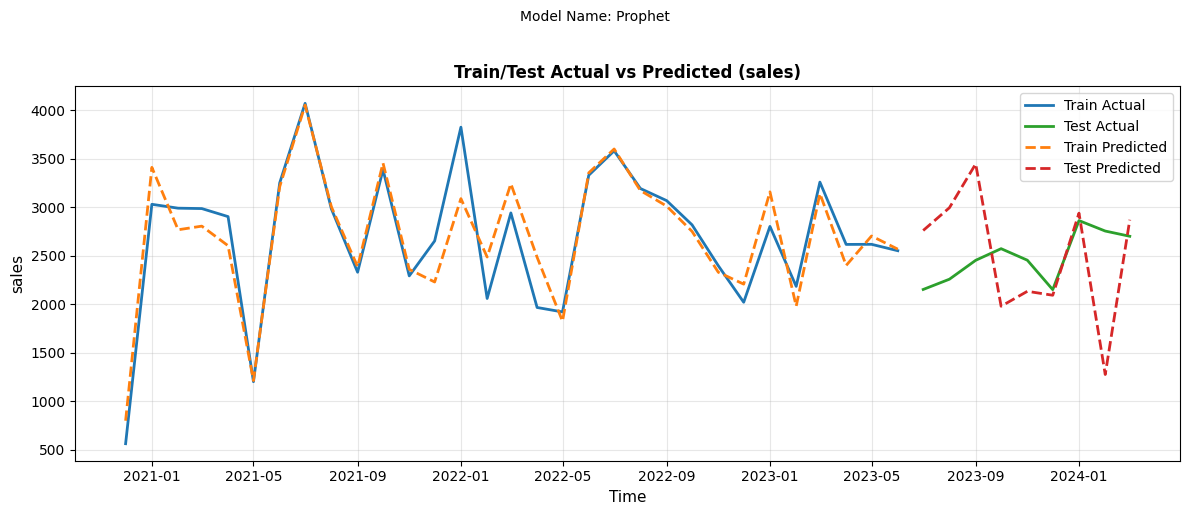

In [12]:
import os

os.makedirs(local_config["output_path"], exist_ok=True)
chart_save = os.path.join(local_config["output_path"], "actual_vs_predicted.png")

print(f"Using regressors: {available_regressors}" if available_regressors else "No regressors found. Using univariate Prophet.")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

plot_forecast_comparison(
    model,
    train_data=train_prophet,
    test_data=test_prophet,
    kpi=kpi,
    figsize=(12, 5),
    colors=None,
    save_path=chart_save,
    show_plot=True
)